In [1]:
import sys
from pathlib import Path

parent_folder = Path.cwd().parent
if str(parent_folder) not in sys.path:
    sys.path.append(str(parent_folder))
    
import warnings
warnings.filterwarnings('ignore')

import scienceplots

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('science')
from analysis import Analysis

# Default bare lattice

Qx
Mean: 4.315988021042609
Median: 4.315992408895844
Std: 1.64995673307147e-05
From Twiss: 4.316000781433129
Qy
Mean: 3.765021833216469
Median: 3.7650179132184785
Std: 1.625433058351619e-05
From Twiss: 3.7650000880425605


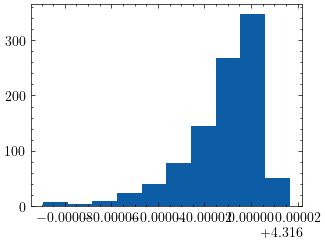

(array([199., 234., 203., 122.,  71.,  59.,  34.,  28.,  15.,  10.]),
 array([3.76500027, 3.76500812, 3.76501598, 3.76502383, 3.76503168,
        3.76503953, 3.76504738, 3.76505523, 3.76506308, 3.76507093,
        3.76507878]),
 <BarContainer object of 10 artists>)

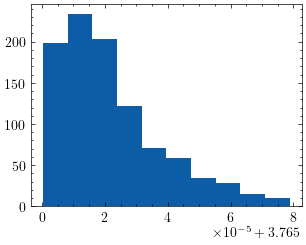

In [19]:
analysis = Analysis('data/default_bare')
Qx = [i for i in analysis.get_tune('x') if i>1]
Qy = [i for i in analysis.get_tune('y') if i>1]

print(r'Qx')
print(f'Mean: {np.mean(Qx)}')
print(f'Median: {np.median(Qx)}')
print(f'Std: {np.std(Qx)}')
print(f'From Twiss: {analysis.qx}')

print(r'Qy')
print(f'Mean: {np.mean(Qy)}')
print(f'Median: {np.median(Qy)}')
print(f'Std: {np.std(Qy)}')
print(f'From Twiss: {analysis.qy}')

plt.hist(Qx)
plt.show()
plt.hist(Qy)

# Bare lattice Sweep Emmitance

(0.2, 0.3)

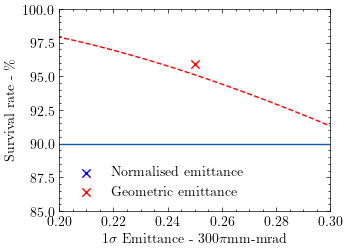

In [151]:
emittance = 300e-6
beta_gamma = 0.3934 

ratio_list = [1, 1/2, 1/4, 1/6, 1/8, 1/10]
survival_list_n = []
survival_list_g = []
for ratio in ratio_list:
    analysis = Analysis(f'data/sweep_emittance_bare_ratio/ratio_{ratio}')
    survival_list_n.append(np.sum(analysis.survivor_mask)/10)
    analysis = Analysis(f'data/sweep_emittance_bare_ratio/ratio_{ratio}_geom')
    survival_list_g.append(np.sum(analysis.survivor_mask)/10)

plt.scatter(ratio_list, survival_list_n, marker='x', c='b', label='Normalised emittance')
plt.scatter(ratio_list, survival_list_g, marker='x', c='r', label='Geometric emittance')

adx = 719.86
ady = 478.95
xi = np.linspace(0,300,1000)
survival_norm = 100*((1 - np.exp(-beta_gamma*adx/(2*xi)))
                    *(1 - np.exp(-beta_gamma*ady/(2*xi))))
survival_geom = 100*((1 - np.exp(-adx/(2*xi)))
                    *(1 - np.exp(-ady/(2*xi))))

plt.plot(xi/300, survival_norm, ls='--', c='b')
plt.plot(xi/300, survival_geom, ls='--', c='r')

plt.plot(xi/300,90*np.ones_like(xi))
plt.xlabel(r'$1\sigma$ Emittance - $300\pi$mm-mrad')
plt.ylabel('Survival rate - \%')
plt.legend()
plt.ylim(85,100)
plt.xlim(0.2,0.3)

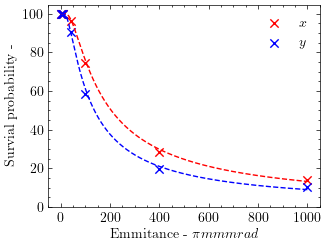

In [106]:
x = np.array([i*1e6 for i in nemitt_list])
yx = np.array([i*1e-1 for i in survival_x])
yy = np.array([i*1e-1 for i in survival_y])
plt.scatter(x, yx, marker='x', c='r', label=r'$x$')
plt.scatter(x, yy, marker='x', c='b', label=r'$y$')


adx = 719.86
ady = 478.95
xi = np.linspace(0,1000,1000)
plt.plot(xi, 100*(1 - np.exp(-beta_gamma*adx/(2*xi))), ls='--', c='r')
plt.plot(xi, 100*(1 - np.exp(-beta_gamma*ady/(2*xi))), ls='--', c='b')
plt.ylim(0)
plt.xlabel(r'Emmitance - $\pi mm mrad$')
plt.ylabel('Survial probability - %')
plt.legend()

Clearly The surival rate for a beam with a given normalsied emittance follows expectation.

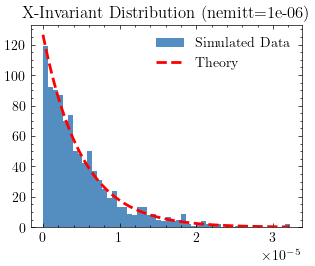

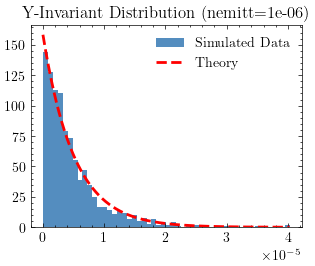

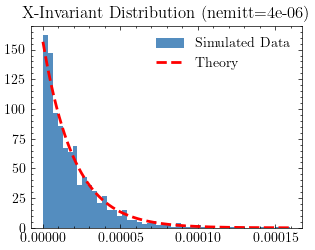

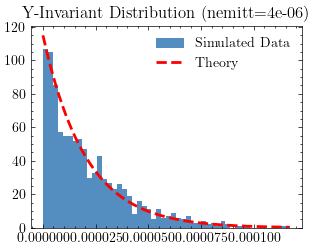

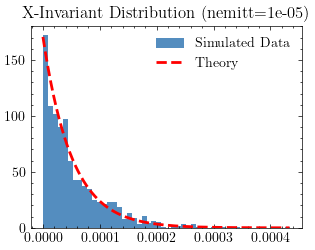

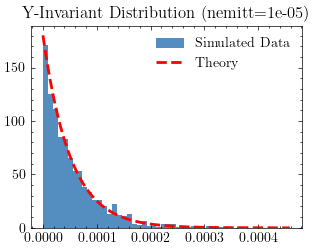

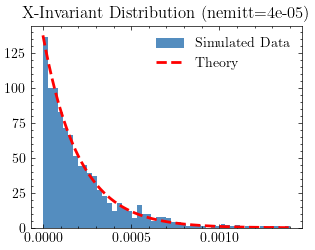

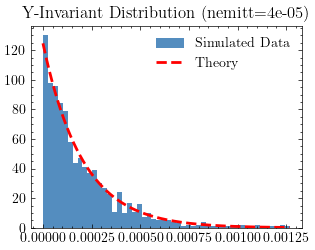

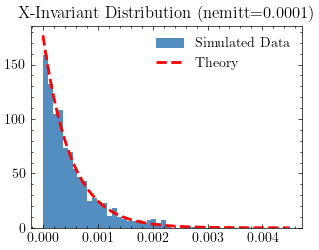

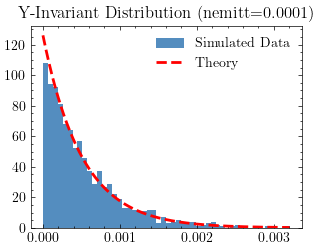

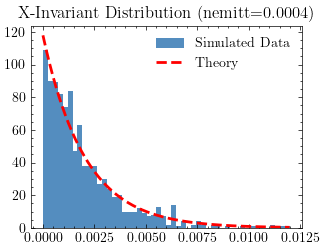

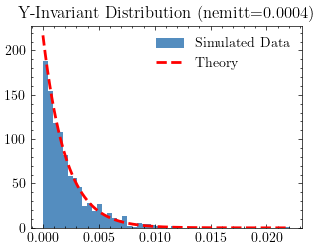

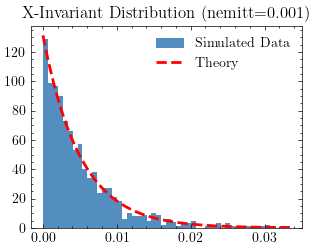

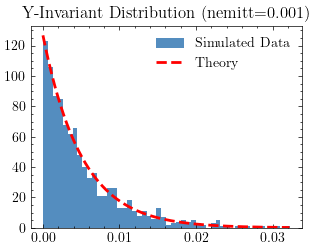

In [99]:
beta_gamma = 0.3934 
for nemitt in nemitt_list:
    eps_g = nemitt/ beta_gamma
    W_mean = 2 * eps_g
    
    analysis = Analysis(f'data/sweep_emittance_x_bare/nemitt_{nemitt}')
    Wx = (gamx*analysis.x.T[0]**2 + 2*alfx*analysis.x.T[0]*analysis.px.T[0] + betx*analysis.px.T[0]**2)
    counts, bins, _ = plt.hist(Wx, bins=50, label='Simulated Data', alpha=0.7)
    bin_width = bins[1] - bins[0]
    x_range = np.linspace(0, np.max(Wx), 1000)
    pdf = (1/W_mean) * np.exp(-x_range/W_mean)
    plt.plot(x_range, pdf * len(Wx) * bin_width, 'r--', lw=2, label='Theory')
    plt.title(f"X-Invariant Distribution (nemitt={nemitt})")
    plt.legend()
    plt.show()

    analysis = Analysis(f'data/sweep_emittance_y_bare/nemitt_{nemitt}')
    Wy = (gamy*analysis.y.T[0]**2 + 2*alfy*analysis.y.T[0]*analysis.py.T[0] + bety*analysis.py.T[0]**2)
    counts, bins, _ = plt.hist(Wy, bins=50, label='Simulated Data', alpha=0.7)
    bin_width = bins[1] - bins[0]
    y_range = np.linspace(0, np.max(Wy), 1000)
    pdf = (1/W_mean) * np.exp(-y_range/W_mean)
    plt.plot(y_range, pdf * len(Wy) * bin_width, 'r--', lw=2, label='Theory')
    plt.title(f"Y-Invariant Distribution (nemitt={nemitt})")
    plt.legend()
    plt.show()

# Direct SC Emittance Sweep

In [111]:
import itertools
nemitt_list = [1e-6, 4e-6, 1e-5]
perms = list(itertools.product(nemitt_list,nemitt_list))

survival = []
for nemitt_x, nemitt_y in perms:
    analysis = Analysis(f'data/sweep_emittance_sc/x:{nemitt_x}_y:{nemitt_y}')
    
    survival.append(np.sum(analysis.survivor_mask))

survival_grid = np.array(survival).reshape(3,3)

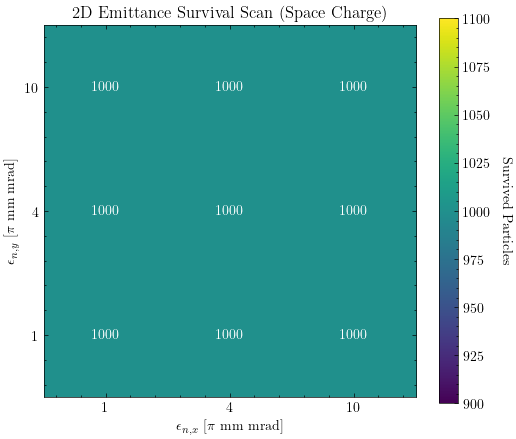

In [113]:
labels = [f'{val*1e6:.0f}' for val in nemitt_list]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(survival_grid, origin='lower', cmap='viridis')

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

cbar = plt.colorbar(im)
cbar.set_label('Survived Particles', rotation=270, labelpad=15)

plt.xlabel(r'$\epsilon_{n,x}$ [$\pi$ mm mrad]')
plt.ylabel(r'$\epsilon_{n,y}$ [$\pi$ mm mrad]')
plt.title('2D Emittance Survival Scan (Space Charge)')

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, int(survival_grid[i, j]), ha="center", va="center", color="w")

plt.show()